In [305]:
import pandas as pd 
import seaborn as sns
import pathlib as pl
import matplotlib.pyplot as plt
from adjustText import adjust_text 

In [306]:
root_path = pl.Path.cwd().parent
data_path = root_path / "data" / "intermed" / "googleplaystore_clean.csv"

In [307]:
data = pd.read_csv(data_path)
data.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000.0,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000.0,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000.0,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [308]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9660 entries, 0 to 9659
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9660 non-null   int64  
 1   App             9660 non-null   str    
 2   Category        9660 non-null   str    
 3   Rating          8197 non-null   float64
 4   Reviews         9660 non-null   str    
 5   Size            9660 non-null   str    
 6   Installs        9659 non-null   float64
 7   Type            9659 non-null   str    
 8   Price           9660 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9660 non-null   str    
 11  Last Updated    9660 non-null   str    
 12  Current Ver     9652 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(1), str(11)
memory usage: 1.0 MB


# Question 1
## “What does the store look like right now?”

“I keep hearing that the Play Store is saturated, but I don’t actually know where. Are there corners of the store that are genuinely packed, or is the crowd concentrated in a few places? And more importantly — are the categories with the most apps actually the ones getting the most downloads, or are users going somewhere else?”


In [309]:
category_analysis = data.groupby("Category").agg({
    "Installs": "mean",
    "App": "count"
})
category_analysis = category_analysis.rename(columns={"App": "App Count", "Installs": "Average Installs"})
category_analysis = category_analysis.sort_values("Average Installs", ascending=False).head(10)

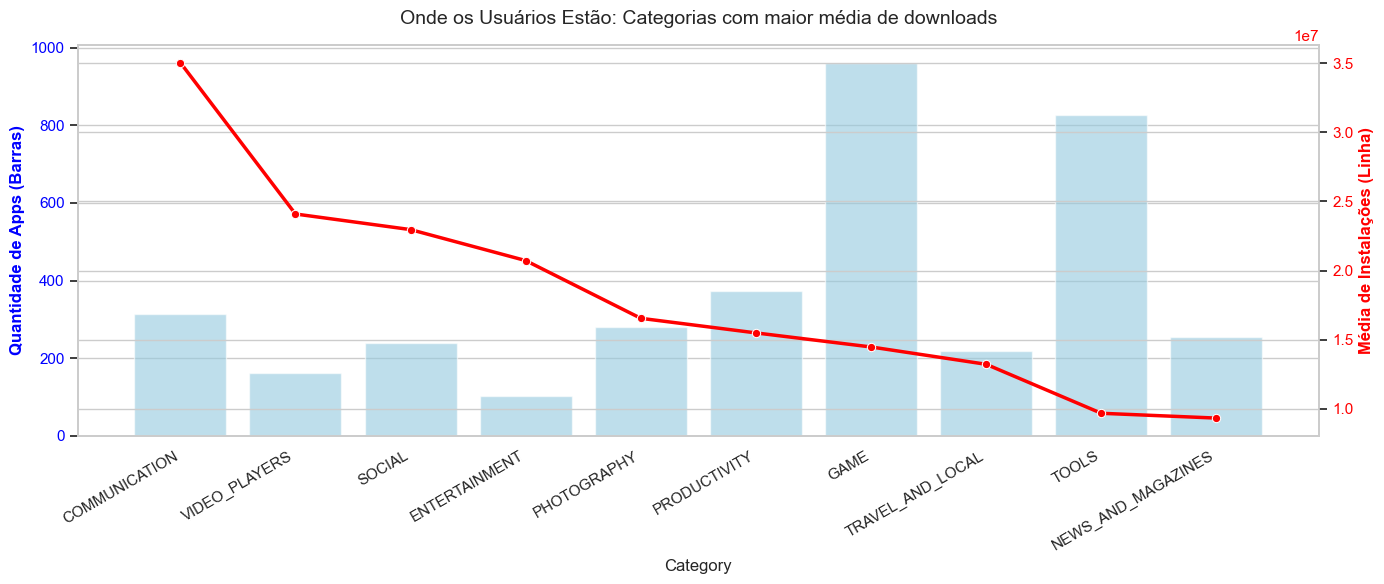

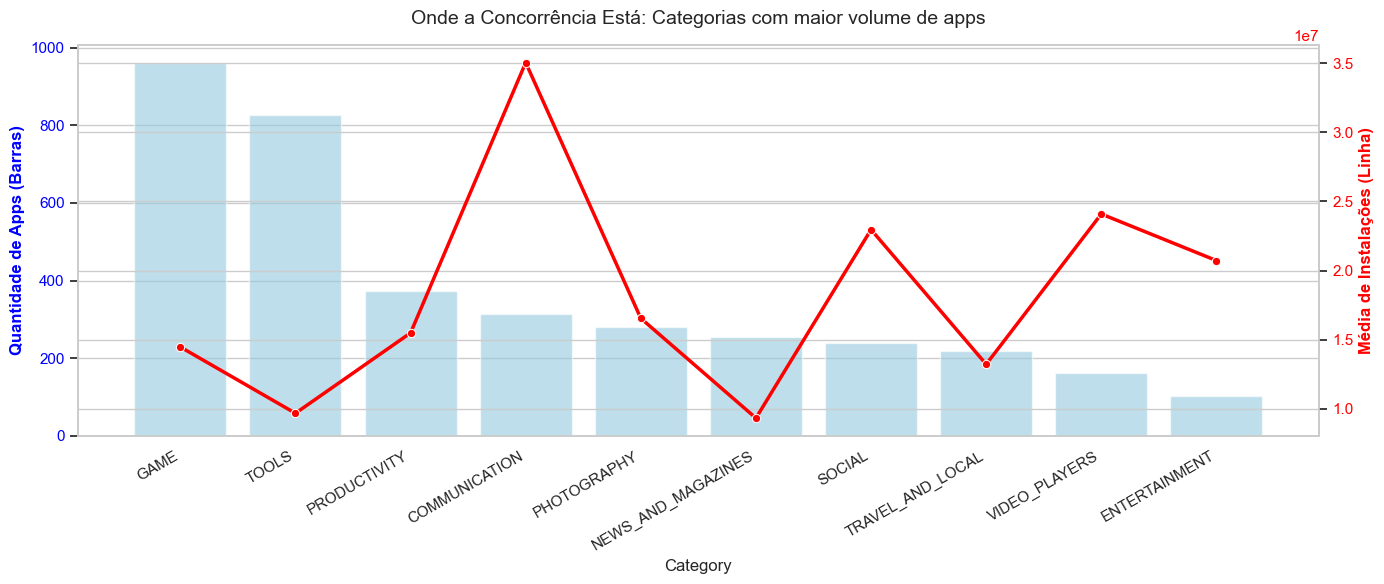

In [310]:

# Configuração do primeiro gráfico: DEMANDA
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

df_demanda = category_analysis.sort_values('Average Installs', ascending=False).head(10)

# Eixo Principal: Quantidade de Apps
ax1 = sns.barplot(x='Category', y='App Count', data=df_demanda, color='skyblue', alpha=0.6)
ax1.set_ylabel('Quantidade de Apps (Barras)', color='blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Onde os Usuários Estão: Categorias com maior média de downloads', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')

# Eixo Gêmeo: Média de Instalações
ax1_twin = ax1.twinx()
sns.lineplot(x='Category', y='Average Installs', data=df_demanda, ax=ax1_twin, marker='o', color='red', linewidth=2.5)
ax1_twin.set_ylabel('Média de Instalações (Linha)', color='red', fontweight='bold')
ax1_twin.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()
#2. Gráfico de Oferta (Foco na Concorrência)
# Este gráfico mostra onde a maioria dos desenvolvedores está "brigando" por espaço.

# Python
# Configuração do segundo gráfico: OFERTA/CONCORRÊNCIA
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

df_oferta = category_analysis.sort_values('App Count', ascending=False).head(10)

# Eixo Principal: Quantidade de Apps
ax2 = sns.barplot(x='Category', y='App Count', data=df_oferta, color='skyblue', alpha=0.6)
ax2.set_ylabel('Quantidade de Apps (Barras)', color='blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_title('Onde a Concorrência Está: Categorias com maior volume de apps', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right')

# Eixo Gêmeo: Média de Instalações
ax2_twin = ax2.twinx()
sns.lineplot(x='Category', y='Average Installs', data=df_oferta, ax=ax2_twin, marker='o', color='red', linewidth=2.5)
ax2_twin.set_ylabel('Média de Instalações (Linha)', color='red', fontweight='bold')
ax2_twin.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.show()

“Also, I’d love to understand where users are happy with what they’ve got. If there’s a genre where everything is rated 4.5+, maybe we don’t need to go there. But if there’s a genre where people keep downloading but seem frustrated, that’s interesting.”

In [311]:
rated_data = data[data["Rating"].notna()]
rated_data.loc[data['Rating'] > 5, 'Rating'] = 5.0
rated_data["Rating"].value_counts().sort_index(ascending=False)


Rating
5.0    272
4.9     85
4.8    221
4.7    442
4.6    683
4.5    848
4.4    895
4.3    897
4.2    810
4.1    621
4.0    513
3.9    359
3.8    286
3.7    224
3.6    167
3.5    156
3.4    126
3.3    100
3.2     63
3.1     69
3.0     81
2.9     45
2.8     40
2.7     23
2.6     24
2.5     20
2.4     19
2.3     20
2.2     14
2.1      8
2.0     12
1.9     11
1.8      8
1.7      8
1.6      4
1.5      3
1.4      3
1.2      1
1.0     16
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

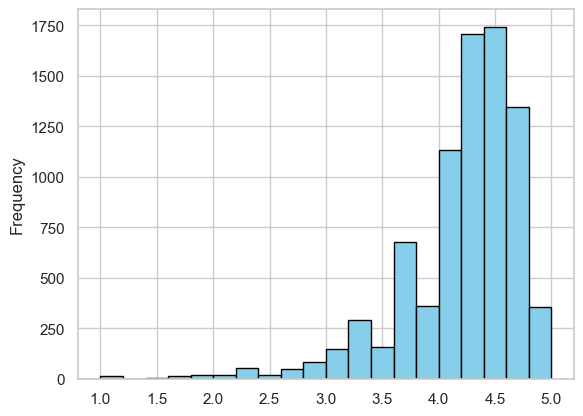

In [312]:
rated_data["Rating"].plot.hist(bins=20, color='skyblue', edgecolor='black')

<Axes: xlabel='Genres'>

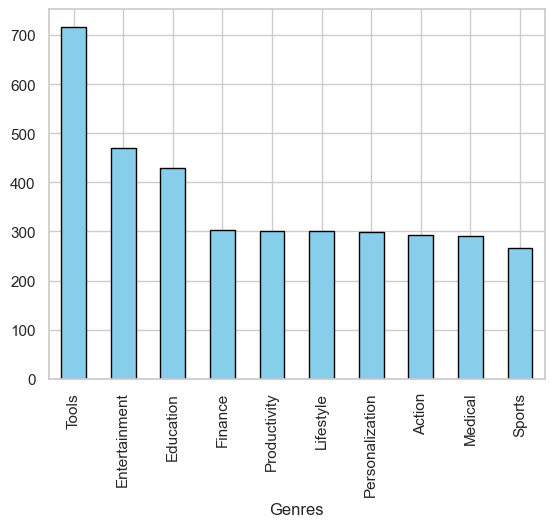

In [313]:
rated_data["Genres"].value_counts().head(10).plot.bar(color='skyblue', edgecolor='black')

In [314]:
# Agrupando por Gênero e calculando as médias
gp_rated_data = rated_data.groupby("Genres").agg({
    "Rating": "mean", 
    "Installs": "mean"
}).reset_index()

# Opcional: Filtrar apenas gêneros com um volume mínimo de downloads para evitar ruído
gp_rated_data = gp_rated_data[(gp_rated_data.Installs > gp_rated_data.Installs.quantile(0.85)) | (gp_rated_data.Rating < gp_rated_data.Rating.quantile(0.05))]

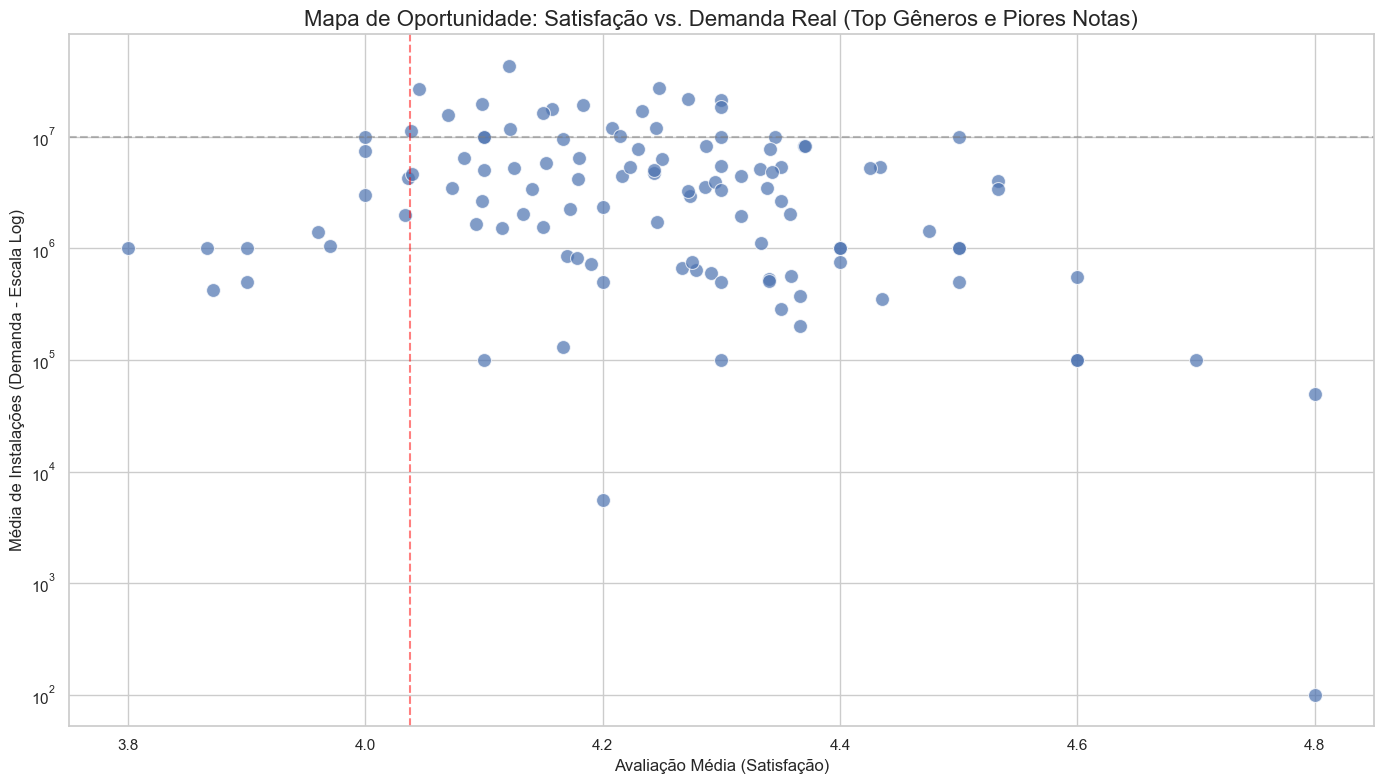

In [315]:
# !pip install adjustText # <-- Rode isso no seu terminal se ainda não tiver instalado
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text # <-- 1. IMPORTAÇÃO OBRIGATÓRIA

# --- PREPARAÇÃO DOS DADOS (Seu código original mantido) ---
gp_rated_data = rated_data.groupby("Genres").agg({
    "Rating": "mean", 
    "Installs": "mean"
}).reset_index()
limite_rating = gp_rated_data['Rating'].quantile(0.1)
limite_installs = gp_rated_data['Installs'].quantile(0.85)



# --- CONFIGURAÇÃO DO GRÁFICO (Seu código original mantido) ---
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Criando o gráfico
ax = sns.scatterplot(data=gp_rated_data, x='Rating', y='Installs', s=100, alpha=0.7)

# Escala Logarítmica
plt.yscale('log')


plt.axvline(limite_rating, color='red', linestyle='--', alpha=0.5) 
plt.axhline(limite_installs, color='gray', linestyle='--', alpha=0.5)


# --- 2. NOVA LÓGICA DE ANOTAÇÃO COM adjustText ---
texts = [] # Criamos uma lista vazia para guardar os objetos de texto



# --- TÍTULOS E LABELS FINAIS ---
plt.title('Mapa de Oportunidade: Satisfação vs. Demanda Real (Top Gêneros e Piores Notas)', fontsize=16)
plt.xlabel('Avaliação Média (Satisfação)', fontsize=12)
plt.ylabel('Média de Instalações (Demanda - Escala Log)', fontsize=12)

plt.tight_layout()
plt.show()

In [316]:
gp_rated_data = rated_data.groupby("Genres").agg({
    "Rating": "mean", 
    "Installs": "mean"
}).reset_index()
limite_rating = gp_rated_data['Rating'].quantile(0.1)
limite_installs = gp_rated_data['Installs'].quantile(0.80)

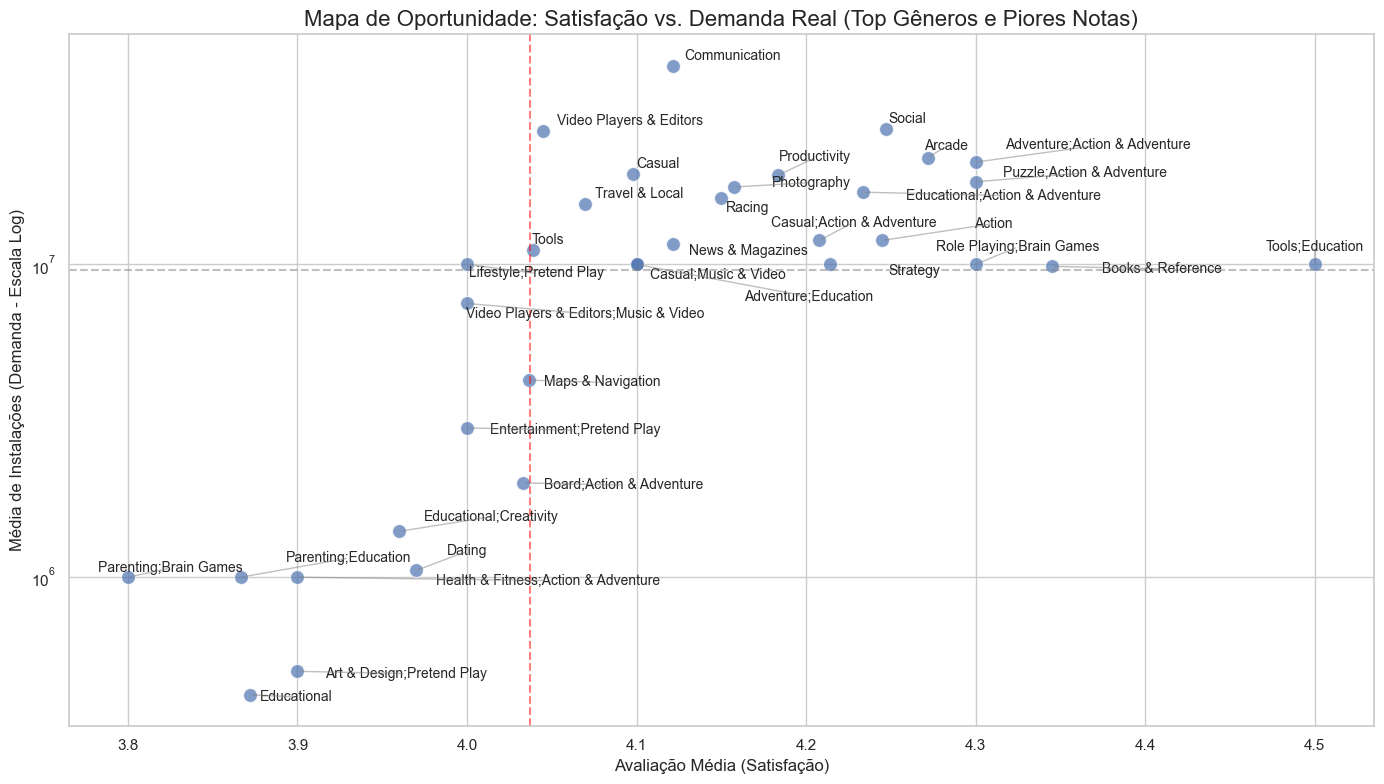

In [317]:



# Filtra o DataFrame original (Top 15% installs ou Piores 5% Rating)
gp_rated_data = gp_rated_data[(gp_rated_data.Installs > limite_installs) | 
                              (gp_rated_data.Rating < limite_rating)]
gp_rated_data = gp_rated_data.reset_index(drop=True)


# --- CONFIGURAÇÃO DO GRÁFICO (Seu código original mantido) ---
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Criando o gráfico
ax = sns.scatterplot(data=gp_rated_data, x='Rating', y='Installs', s=100, alpha=0.7)

# Escala Logarítmica
plt.yscale('log')


plt.axvline(limite_rating, color='red', linestyle='--', alpha=0.5) 
plt.axhline(limite_installs, color='gray', linestyle='--', alpha=0.5)


# --- 2. NOVA LÓGICA DE ANOTAÇÃO COM adjustText ---
texts = [] # Criamos uma lista vazia para guardar os objetos de texto

for i in range(gp_rated_data.shape[0]):
    # Pegamos os valores da linha atual
    rating_val = gp_rated_data.Rating[i]
    installs_val = gp_rated_data.Installs[i]
    genre_name = gp_rated_data.Genres[i]
    
    # Criamos o objeto de texto, mas NÃO desenhamos ainda.
    # Adicionamos ele à nossa lista 'texts'.
    texts.append(plt.text(rating_val, installs_val, genre_name, fontsize=10))


# --- 3. MÁGICA: adjustText ---
# Chamamos a função passando a lista de textos.
# force_points/text e expand_points ajustam quão "agressivo" é o afastamento.
# arrowprops adiciona setas cinzas ligando o nome ao ponto original.
adjust_text(texts, force_points=0.2, force_text=0.2, expand_points=(1.5, 1.5),
            arrowprops=dict(arrowstyle="-", color='gray', alpha=0.5))


# --- TÍTULOS E LABELS FINAIS ---
plt.title('Mapa de Oportunidade: Satisfação vs. Demanda Real (Top Gêneros e Piores Notas)', fontsize=16)
plt.xlabel('Avaliação Média (Satisfação)', fontsize=12)
plt.ylabel('Média de Instalações (Demanda - Escala Log)', fontsize=12)

plt.tight_layout()
plt.show()

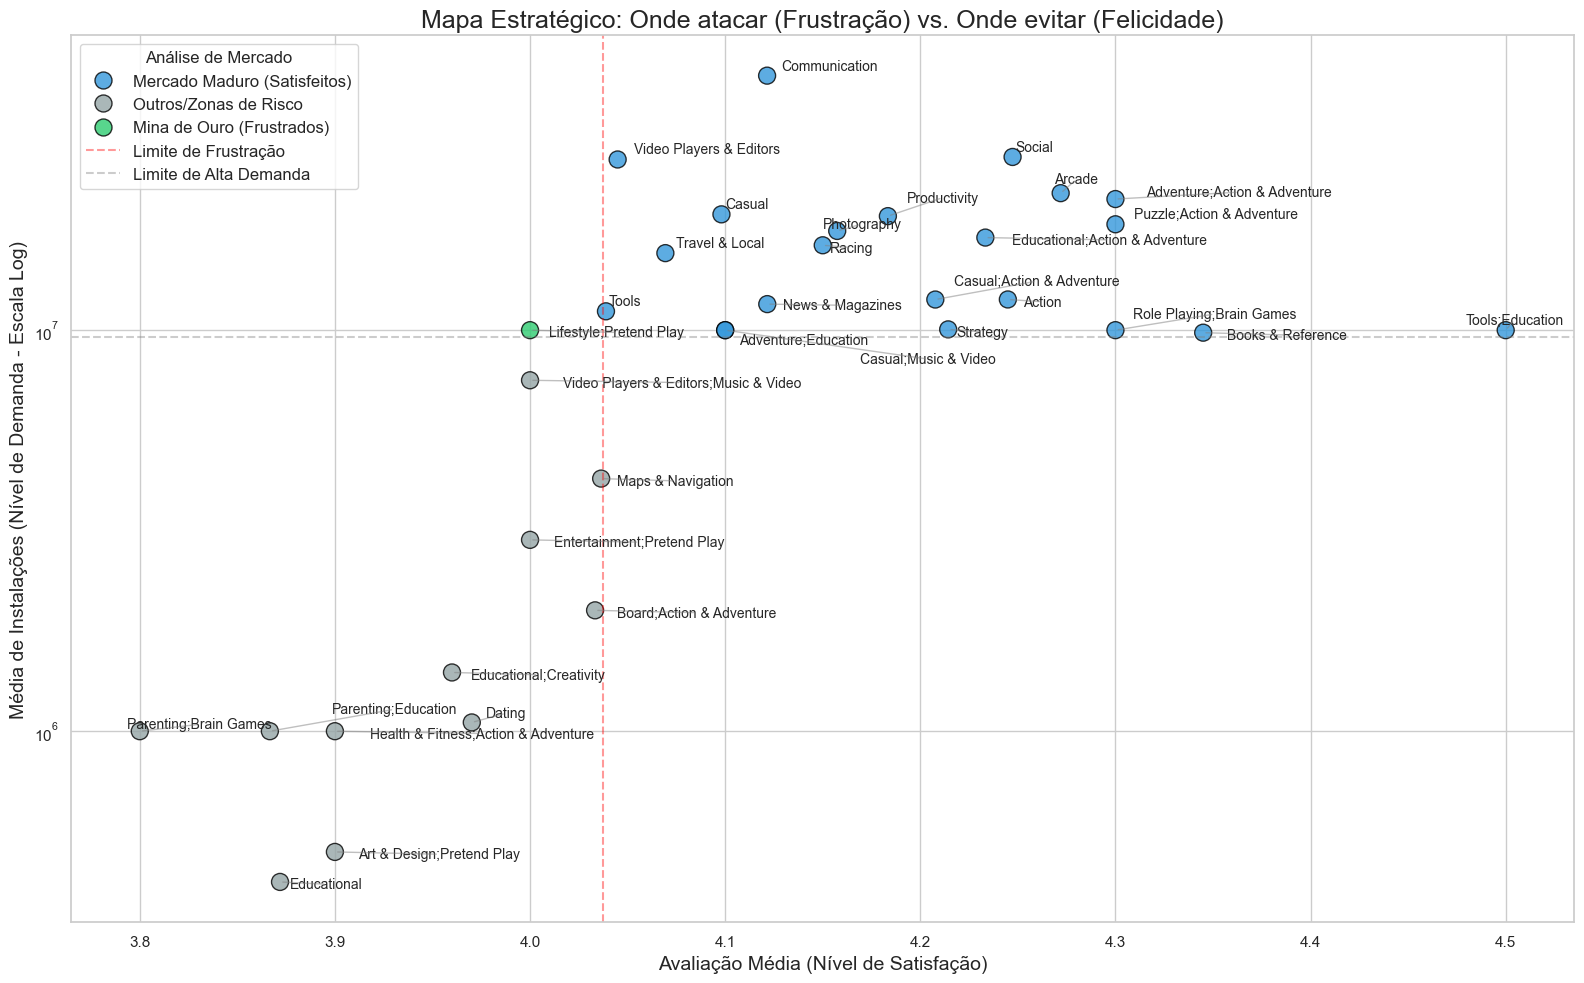

In [318]:


# 1. NOVA LÓGICA DE CLASSIFICAÇÃO (Foco em Frustração vs. Felicidade)
def classificar_oportunidade(row):
    # Frustrados: Muitos downloads, mas nota abaixo do limite
    if row['Installs'] >= limite_installs and row['Rating'] < limite_rating:
        return 'Mina de Ouro (Frustrados)'
    # Felizes: Muitos downloads e nota alta
    elif row['Installs'] >= limite_installs and row['Rating'] >= limite_rating:
        return 'Mercado Maduro (Satisfeitos)'
    else:
        # Simplificando para focar nos dois extremos que você quer
        return 'Outros/Zonas de Risco'

gp_rated_data['Categoria'] = gp_rated_data.apply(classificar_oportunidade, axis=1)

# 2. PALETA DE CORES TEMÁTICA
cores = {
    'Mina de Ouro (Frustrados)': '#2ecc71',      # Verde (Ataque aqui!)
    'Mercado Maduro (Satisfeitos)': '#3498db',   # Azul (Evite se puder)
    'Outros/Zonas de Risco': '#95a5a6'            # Cinza (Pouco interessante)
}

# --- CONFIGURAÇÃO DO GRÁFICO ---
plt.figure(figsize=(16, 10)) # Aumentei um pouco para acomodar melhor os textos
sns.set_theme(style="whitegrid")

# 3. CRIANDO O GRÁFICO COM HUE
ax = sns.scatterplot(
    data=gp_rated_data, 
    x='Rating', 
    y='Installs', 
    hue='Categoria', 
    palette=cores,
    s=150, # Pontos maiores para destaque
    alpha=0.8,
    edgecolor='black' # Borda preta para contraste
)

plt.yscale('log') # Escala Logarítmica obrigatória

# Linhas de referência (divisão dos quadrantes)
plt.axvline(limite_rating, color='red', linestyle='--', alpha=0.4, label='Limite de Frustração')
plt.axhline(limite_installs, color='gray', linestyle='--', alpha=0.4, label='Limite de Alta Demanda')

# --- 4. A MÁGICA: adjustText (Reaplicado com a nova estrutura) ---
texts = []
# Iteramos sobre o dataframe para criar as anotações
for i, row in gp_rated_data.iterrows():
    texts.append(plt.text(row['Rating'], row['Installs'], row['Genres'], fontsize=10))

# Chamamos a função para ajustar o posicionamento e adicionar setas
# Aumentei ligeiramente force_text para garantir que fiquem bem separados
adjust_text(texts, force_points=0.2, force_text=0.4, expand_points=(1.8, 1.8),
            arrowprops=dict(arrowstyle="-", color='gray', alpha=0.5))

# TÍTULOS E LEGENDAS FINAIS
plt.title('Mapa Estratégico: Onde atacar (Frustração) vs. Onde evitar (Felicidade)', fontsize=18)
plt.xlabel('Avaliação Média (Nível de Satisfação)', fontsize=14)
plt.ylabel('Média de Instalações (Nível de Demanda - Escala Log)', fontsize=14)
plt.legend(title='Análise de Mercado', fontsize=12)

plt.tight_layout()
plt.show()